In [14]:
import pandas as pd
df = pd.read_csv("../data/processed/clean_twitter_training.csv")

df['clean_tweet'].isna().sum()
df = df.dropna(subset=['clean_tweet'])

df.head()

,tweet_id,entity,sentiment,tweet,clean_tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im get borderland murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,come border kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im get borderland kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im come borderland murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im get borderland murder


In [15]:
print(df.shape)
df.head()

(72289, 5)


,tweet_id,entity,sentiment,tweet,clean_tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im get borderland murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,come border kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im get borderland kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im come borderland murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im get borderland murder


In [3]:
print(df.columns)

Index(['id', 'label', 'tweet', 'clean_tweet'], dtype='object')


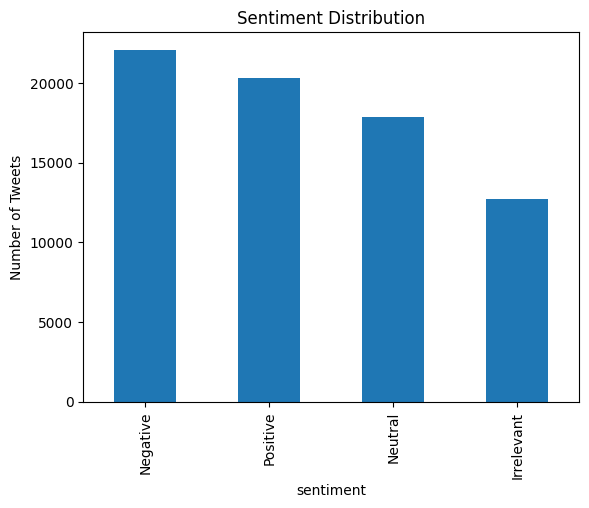

In [3]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [4]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
Negative      30.252826
Positive      27.858856
Neutral       24.449469
Irrelevant    17.438849
Name: proportion, dtype: float64

### Top 20 Most Common Words


In [8]:
from collections import Counter

all_words = " ".join(df['clean_tweet'])

words = all_words.split()

common_words = Counter(words).most_common(20)

common_words

[('game', 10903),
 ('play', 6960),
 ('get', 5648),
 ('like', 5217),
 ('im', 4942),
 ('fuck', 4360),
 ('love', 3867),
 ('go', 3848),
 ('one', 3716),
 ('good', 3591),
 ('time', 3554),
 ('realli', 3260),
 ('new', 3210),
 ('see', 3131),
 ('look', 2981),
 ('make', 2925),
 ('peopl', 2918),
 ('johnson', 2897),
 ('shit', 2836),
 ('thank', 2826)]

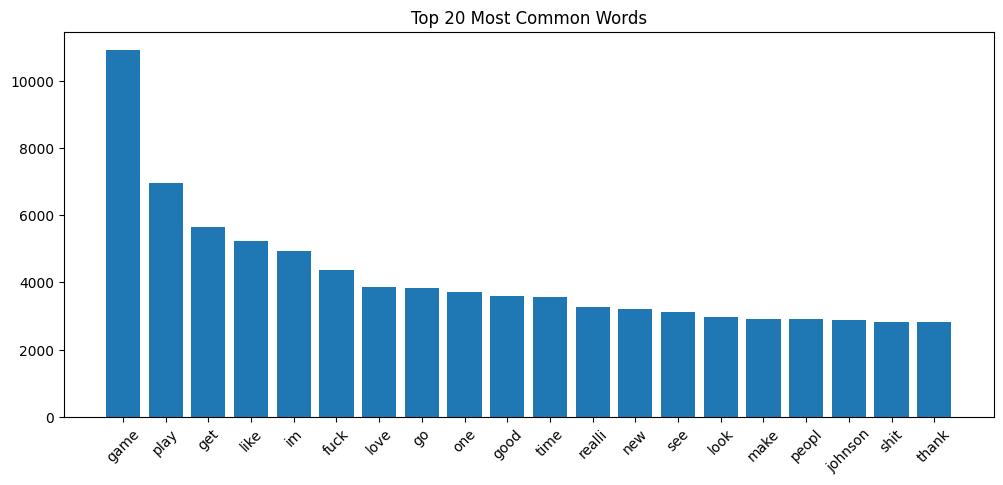

In [9]:
import matplotlib.pyplot as plt

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12,5))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

In [17]:
df['sentiment'].value_counts()

sentiment
Negative      21893
Positive      20153
Neutral       17632
Irrelevant    12611
Name: count, dtype: int64

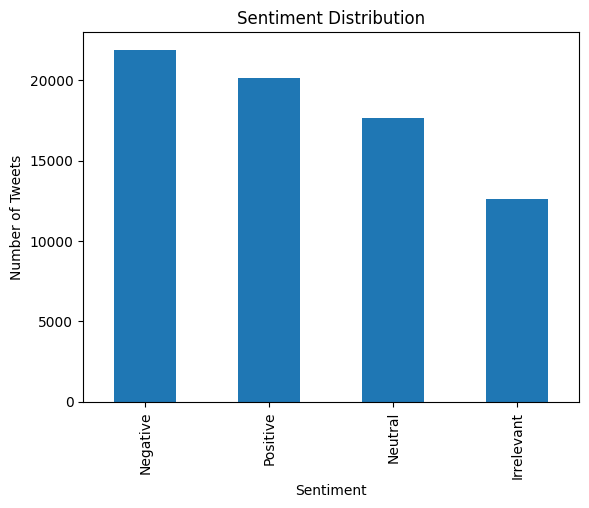

In [18]:

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [19]:
sentiment_percent = (
    df['sentiment']
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percent)

sentiment
Negative      30.285382
Positive      27.878377
Neutral       24.390986
Irrelevant    17.445254
Name: proportion, dtype: float64


### Top Positive Entities

In [22]:
positive_df = df[df['sentiment'] == 'Positive']

positive_df['entity'].value_counts().head(10)

entity
AssassinsCreed               1416
Borderlands                   985
Cyberpunk2077                 928
PlayStation5(PS5)             926
RedDeadRedemption(RDR)        908
CallOfDutyBlackopsColdWar     845
Hearthstone                   811
Nvidia                        778
Xbox(Xseries)                 773
HomeDepot                     746
Name: count, dtype: int64

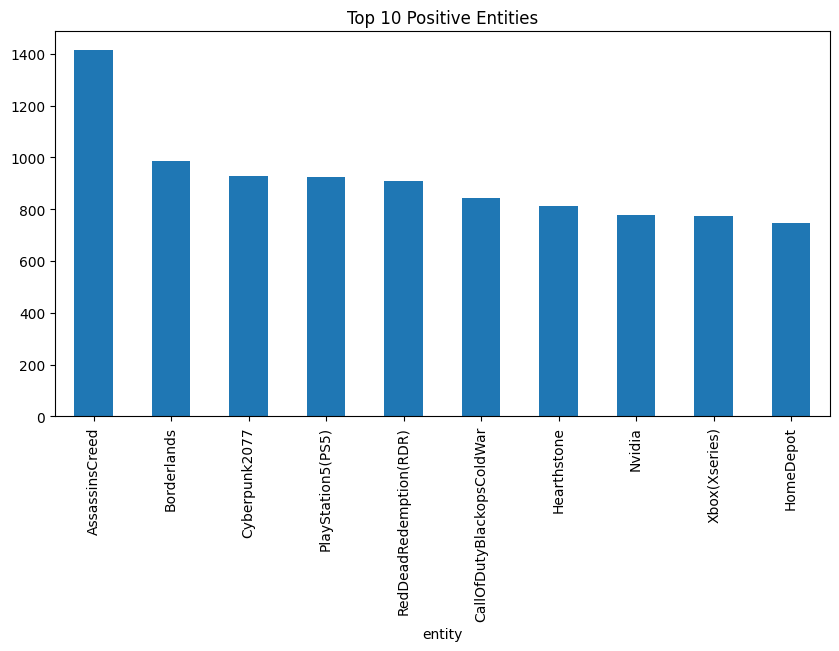

In [24]:
positive_df['entity'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Positive Entities")
plt.show()

### Top Negative Entities

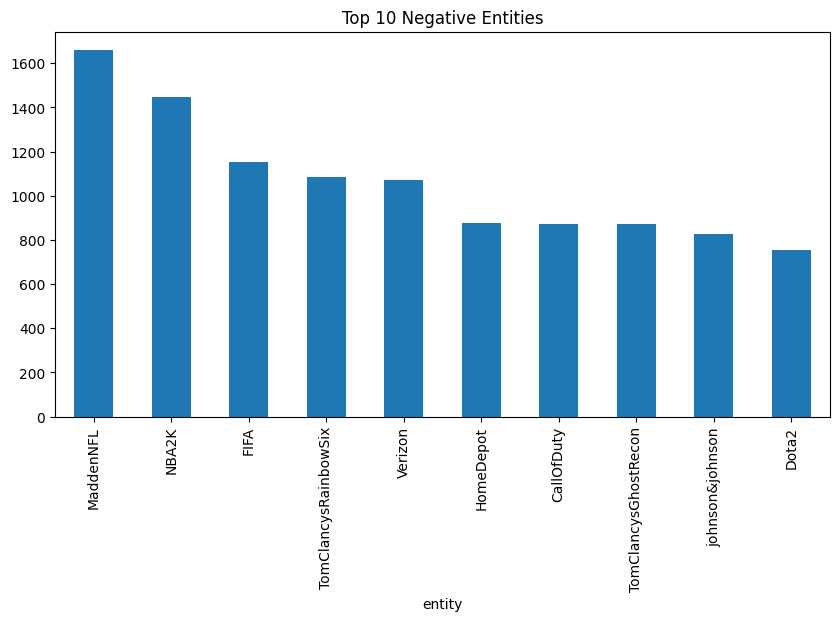

In [25]:
negative_df = df[df['sentiment'] == 'Negative']

negative_df['entity'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Negative Entities")
plt.show()

### Entity vs Sentiment Heatmap

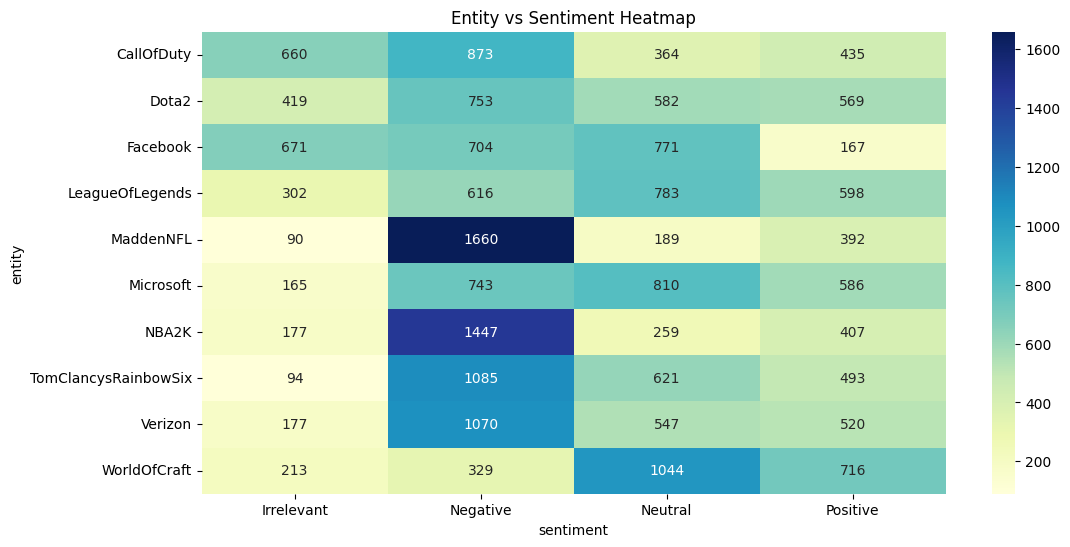

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

top_entities = df['entity'].value_counts().head(10).index

filtered_df = df[df['entity'].isin(top_entities)]

heatmap_data = pd.crosstab(
    filtered_df['entity'],
    filtered_df['sentiment']
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Entity vs Sentiment Heatmap")
plt.show()

### Overall Word Cloud

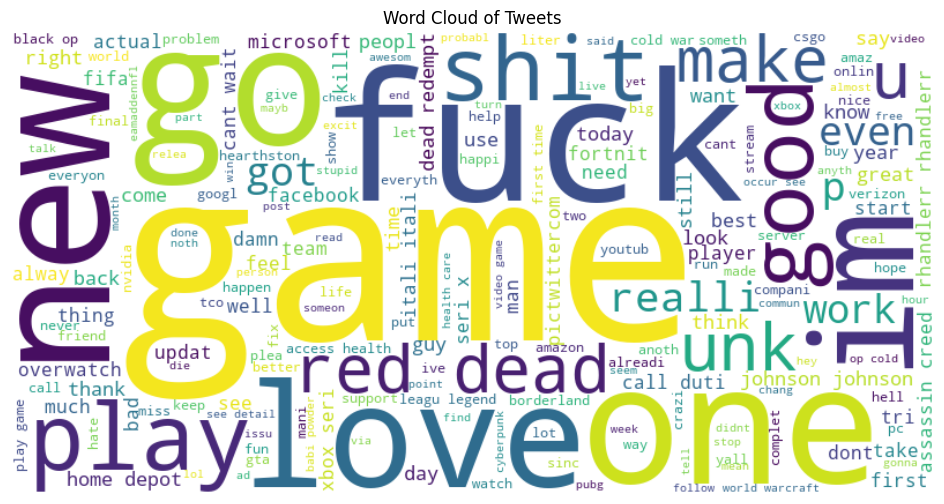

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tweets")
plt.show()

### Positive Tweet Word Cloud

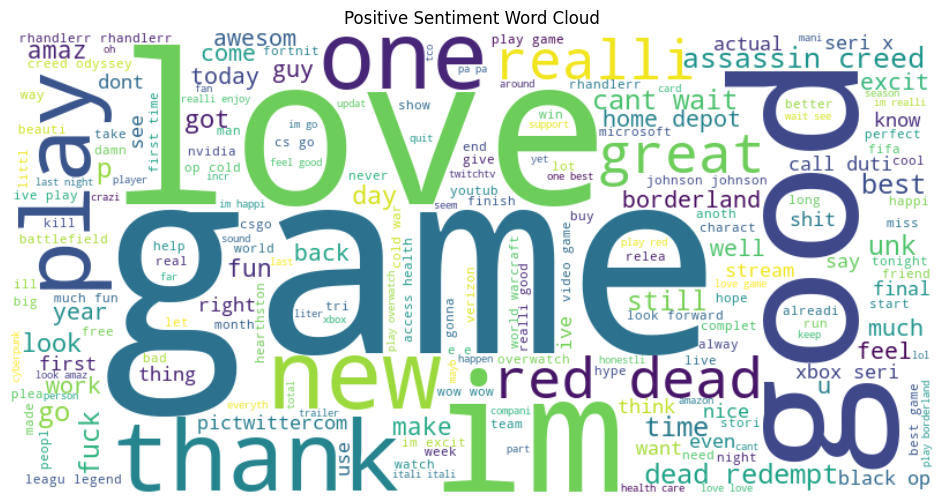

In [30]:
positive_text = " ".join(
    df[df['sentiment']=='Positive']['clean_tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Sentiment Word Cloud")
plt.show()

### Negative Tweet Word Cloud

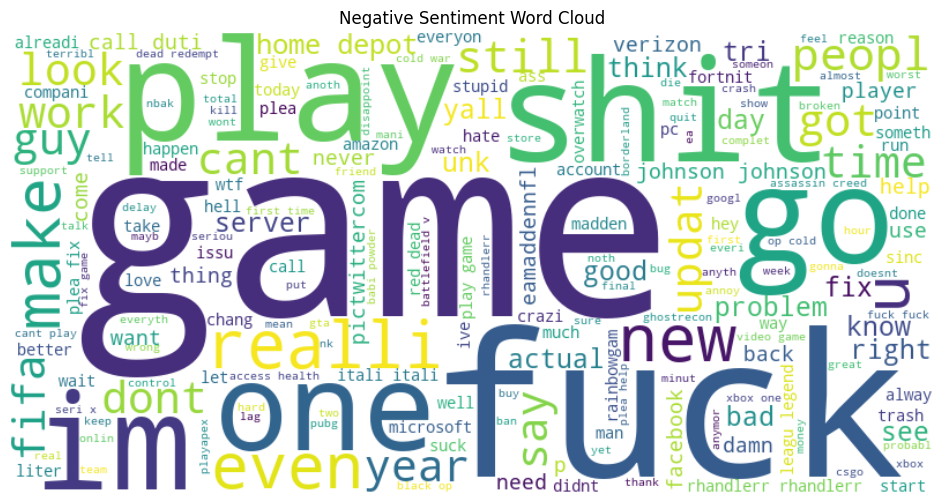

In [33]:
negative_text = " ".join(
    df[df['sentiment']=='Negative']['clean_tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Sentiment Word Cloud")
plt.show()